# 02 · A two-qubit variational ground-state calculation

**Question:** Can a one-parameter trial circuit recover the ground-state energy
of a small interacting Hamiltonian?

This develops the VQE exercise in my original practice notebook. The main
improvement is validation: compare the optimized energy and state with a full
matrix diagonalization, and plot the energy landscape and optimization trace.
The code uses ideal statevector expectations, with no measurement noise.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector, state_fidelity

## 1. Define the problem and an independent reference

Use $H=-Z_0-Z_1+0.5X_0X_1$ in dimensionless units.
`SparsePauliOp` represents the sum; `to_matrix()` gives the $4\times4$ matrix
used for exact diagonalization. `np.linalg.eigh` is appropriate because H is
Hermitian. Its lowest eigenvalue is the reference energy, independent of VQE.

In [2]:
H = SparsePauliOp.from_list([('IZ', -1.0), ('ZI', -1.0), ('XX', 0.5)])
matrix = H.to_matrix()
eigenvalues, eigenvectors = np.linalg.eigh(matrix)
exact_energy = float(eigenvalues[0])
exact_state = Statevector(eigenvectors[:, 0])
print('Hamiltonian matrix:\n', matrix.real)
print('Eigenvalues:', eigenvalues)
print('Exact ground-state energy:', exact_energy)

Hamiltonian matrix:
 [[-2.   0.   0.   0.5]
 [ 0.   0.   0.5  0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.5  0.   0.   2. ]]
Eigenvalues: [-2.06155281 -0.5         0.5         2.06155281]
Exact ground-state energy: -2.0615528128088303


## 2. Choose an ansatz that can represent this ground state

An ansatz is the adjustable trial state. Apply $R_y(\theta)$ to qubit 0,
then CX from qubit 0 to qubit 1:

$$|\psi(\theta)\rangle=\cos(\theta/2)|00\rangle+\sin(\theta/2)|11\rangle.$$

This spans a **real, even-parity** family, rather than arbitrary two-qubit states.
For this specific Hamiltonian, the ground state lies in that family. A different
Hamiltonian might require a richer circuit.

Initial trial-state amplitudes: [0.96891242+0.j 0.        +0.j 0.        +0.j 0.24740396+0.j]


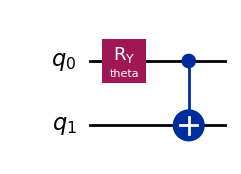

In [3]:
theta = Parameter('theta')
ansatz = QuantumCircuit(2, name='Trial state')
ansatz.ry(theta, 0)
ansatz.cx(0, 1)
display(ansatz.draw('mpl'))
plt.close('all')  # Prevent a second automatic inline display.

test_circuit = ansatz.assign_parameters({theta: 0.5})
test_state = Statevector.from_instruction(test_circuit)
print('Initial trial-state amplitudes:', test_state.data)

## 3. Derive and check the cost function

For this ansatz, $\langle Z_0\rangle=\langle Z_1\rangle=\cos\theta$ and
$\langle X_0X_1\rangle=\sin\theta$, giving

$$E(\theta)=-2\cos\theta+0.5\sin\theta.$$

The analytical minimum is $-\sqrt{4.25}$ at
$\theta=-\arctan(0.25)$ modulo $2\pi$. The full diagonalization above confirms
that this ansatz minimum is also the global ground-state energy.

In [4]:
def analytic_energy(angle):
    return -2 * np.cos(angle) + 0.5 * np.sin(angle)

history = []

def energy_function(values):
    # Bind a fresh circuit, evaluate its state, and return one scalar cost.
    angle = float(values[0])
    circuit = ansatz.assign_parameters({theta: angle})
    state = Statevector.from_instruction(circuit)
    energy = float(state.expectation_value(H).real)
    history.append((angle, energy))
    return energy

# An analytical check prevents a sign or parameter-binding error going unnoticed.
for angle in np.linspace(-np.pi, np.pi, 9):
    np.testing.assert_allclose(energy_function([angle]), analytic_energy(angle), atol=1e-12)
history.clear()  # The following trace should contain only optimizer evaluations.

## 4. Run the variational loop

COBYLA is a classical, derivative-free optimizer. It selects an angle, calls
the quantum-state cost function, and chooses another angle to lower the energy.
The algorithmic loop is hybrid in structure, but both parts run locally here.
These are **objective evaluations**, not necessarily accepted iterations.

In [5]:
result = minimize(
    energy_function,
    x0=[0.5],
    method='COBYLA',
    options={'tol': 1e-8, 'maxiter': 300},
)
assert result.success, result.message
optimal_theta = float(result.x[0])
estimated_energy = float(result.fun)
ground_circuit = ansatz.assign_parameters({theta: optimal_theta})
ground_state = Statevector.from_instruction(ground_circuit)
fidelity = float(state_fidelity(ground_state, exact_state))
error = abs(estimated_energy - exact_energy)

print(f'Optimal theta:       {optimal_theta:.10f} radians')
print(f'VQE energy:          {estimated_energy:.12f}')
print(f'Exact energy:        {exact_energy:.12f}')
print(f'Absolute error:      {error:.3e}')
print(f'Ground-state fidelity: {fidelity:.12f}')
print(f'Objective evaluations: {result.nfev}')
assert error < 1e-8
assert fidelity > 1 - 1e-8

Optimal theta:       -0.2449786500 radians
VQE energy:          -2.061552812809
Exact energy:        -2.061552812809
Absolute error:      0.000e+00
Ground-state fidelity: 1.000000000000
Objective evaluations: 43


Fidelity is $|\langle\psi_{exact}|\psi_{VQE}\rangle|^2$. It compares the states
without treating an arbitrary global phase as a physical difference.
An energy match alone is less informative for a degenerate or nearly degenerate
problem; this example also checks the ground-state overlap.

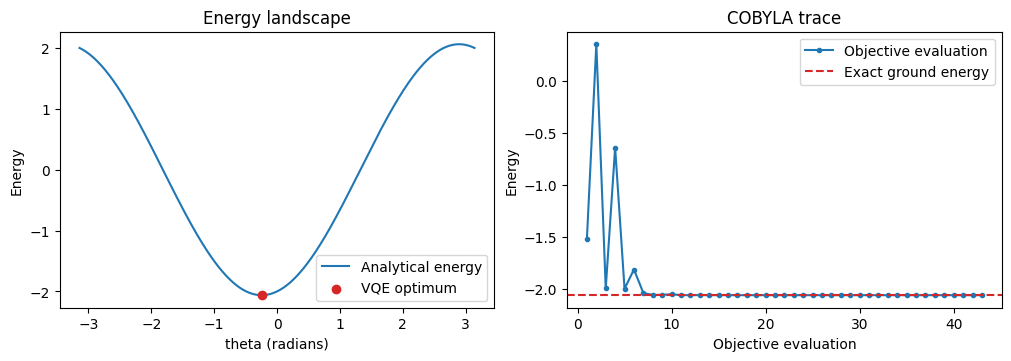

In [6]:
angles = np.linspace(-np.pi, np.pi, 401)
trace = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(angles, analytic_energy(angles), label='Analytical energy')
axes[0].scatter([optimal_theta], [estimated_energy], color='tab:red', label='VQE optimum', zorder=3)
axes[0].set(xlabel='theta (radians)', ylabel='Energy', title='Energy landscape')
axes[0].legend()
axes[1].plot(np.arange(1, len(trace) + 1), trace[:, 1], '.-', label='Objective evaluation')
axes[1].axhline(exact_energy, linestyle='--', color='tab:red', label='Exact ground energy')
axes[1].set(xlabel='Objective evaluation', ylabel='Energy', title='COBYLA trace')
axes[1].legend()
plt.show()

## 5. Cross-check using the Estimator primitive

The cost above uses `Statevector.expectation_value`. This final cell computes
the same observable with the V2 `StatevectorEstimator` interface.

In [7]:
estimator_energy = float(StatevectorEstimator().run([(ground_circuit, H)]).result()[0].data.evs)
np.testing.assert_allclose(estimator_energy, estimated_energy, atol=1e-12)
print('Estimator energy:', estimator_energy)
print('Ground-state probabilities:', ground_state.probabilities_dict())

Estimator energy: -2.06155281280883
Ground-state probabilities: {np.str_('00'): np.float64(0.985071251664532), np.str_('11'): np.float64(0.014928748335467996)}


## Interpretation and limits

The one-parameter circuit recovers the ground state of this selected two-qubit
Hamiltonian. That is a correctness demonstration, not evidence of quantum
advantage: a 4x4 matrix is easily solved classically. The statevector cost has no
finite-shot noise, device noise, or measurement-grouping overhead. Dense exact
diagonalization also becomes impractical as the qubit count grows.

The reusable implementation is in
[experiments.py](../src/qiskit_portfolio/experiments.py), with independent checks
in [test_experiments.py](../tests/test_experiments.py).
Next, [Notebook 03](03_evolution_and_transpilation.ipynb) asks what happens when
this state is evolved and compiled into a gate basis.